In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, shapiro, kruskal, mannwhitneyu, tukey_hsd, ttest_ind
from statsmodels.stats.oneway import anova_oneway

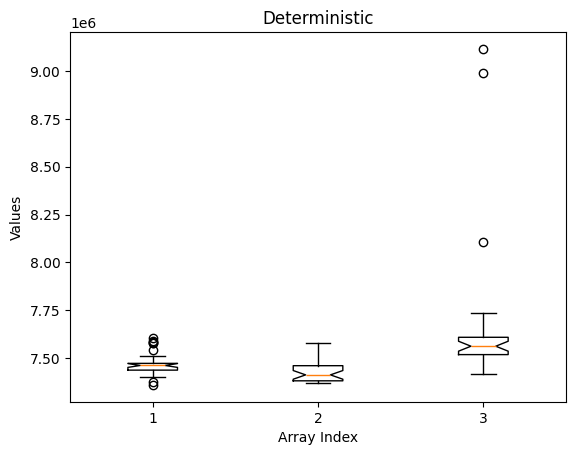

In [20]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

filename = 'sets1/FX_values_0.npz'
plot_boxplots(filename, "Deterministic")

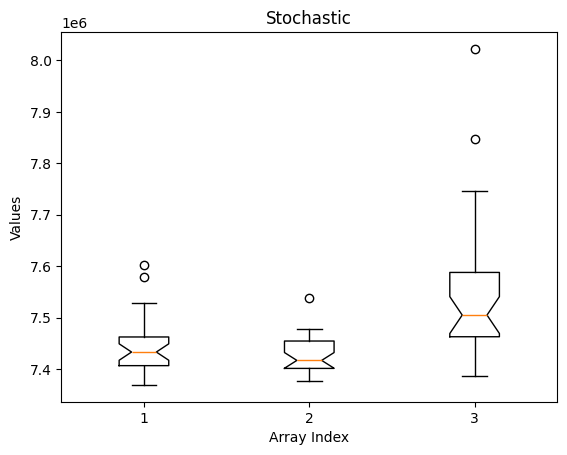

In [21]:
filename = 'sets2/FX_values_1.npz'
plot_boxplots(filename, "Stochastic")

In [22]:
filename = 'sets1/fX_values_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]

filename = 'sets1/fX_values_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]

## Shapiro-Wilk test

H0: the data was drawn from a normal distribution

If p-value < 0.05, reject H0 (the samples are not normally distributed).

In [13]:
print('Deterministic:')
print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))

# Based on the results, none of them are normally distributed.

Deterministic:
ShapiroResult(statistic=0.9030573332766695, pvalue=0.009984966448582476)
ShapiroResult(statistic=0.8931635344605707, pvalue=0.005738138326069872)
ShapiroResult(statistic=0.5157443046960232, pvalue=7.89199721841489e-09)


## Tests that do NOT assume the samples are normally distributed.

In [14]:
# perform Kruskal-Wallis test
# H0: the medians of the groups are equal

# does not assume normality

print(kruskal(a0, b0, c0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=35.49211098841331, pvalue=1.963297092007634e-08)


In [27]:
# perform Mann-Whitney U test
# H0: the distribution underlying the two samples is the same

# does not assume normality

#  The alternative hypothesis is that the distribution of the first sample is stochastically 
# less than the distribution of the second sample. This means that observations in the first sample 
# tend to have smaller values than those in the second sample.

print('Deterministic:')
print(f"a vs b: {mannwhitneyu(a0, b0, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='less')}")

Deterministic:
a vs b: MannwhitneyuResult(statistic=640.5, pvalue=0.0024428024498420998)
a vs c: MannwhitneyuResult(statistic=188.0, pvalue=5.515488291383008e-05)
b vs c: MannwhitneyuResult(statistic=77.0, pvalue=1.772870072690108e-08)


In summary, based on the Mann-Whitney U tests:

There is no evidence to suggest that the distribution of a is stochastically less than the distribution of b.

There is evidence to suggest that the distribution of a is stochastically less than the distribution of c, and similarly, the distribution of b is stochastically less than the distribution of c.

So, the distribution with smaller values between a, b, and c is *a*.

## Tests that assume the samples are normally distributed.

In [23]:

# performe ANOVA test
# H0: all means are equal
# If p-value < 0.05, reject H0
# Assumptions: normality; the samples are independent; standard deviation is equal

print(f_oneway(a0, b0, c0))

# h0 is rejected, meaning that the means are not equal

F_onewayResult(statistic=9.013819891813426, pvalue=0.0002769367738672324)


In [25]:
# Comparar as médias de 3 ou mais grupos independentes para determinar se pelo menos um dos grupos 
# é significativamente diferente dos outros
# H0: the means of the samples from different groups are equal.

anova_oneway(data, use_var='unequal')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 10.321188023377681
pvalue = 0.00017118723291028793
df = (2.0, 51.24428810684149)
df_num = 2.0
df_denom = 51.24428810684149
nobs_t = 90.0
n_groups = 3
means = array([7439804.66650483, 7426701.79942681, 7548233.90952703])
nobs = array([30., 30., 30.])
vars_ = array([3.29395513e+09, 1.57206110e+09, 1.97277903e+10])
use_var = 'unequal'
welch_correction = True
tuple = (10.321188023377681, 0.00017118723291028793)

In [17]:
# perform Tukey's honestly significant difference test -> performs pairwise comparisons of the means
# H0: the distribution underlying the samples all have the same mean

# While the Tukey HSD test does not have a strict normality assumption, 
# it does assume homogeneity of variances (i.e., that the variances are equal across groups)

print(tukey_hsd(a0, b0, c0))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)  42306.957     0.764-101753.052186366.967
 (0 - 2) -197956.146     0.004-342016.155-53896.136
 (1 - 0) -42306.957     0.764-186366.967101753.052
 (1 - 2) -240263.103     0.000-384323.113-96203.093
 (2 - 0) 197956.146     0.004 53896.136342016.155
 (2 - 1) 240263.103     0.000 96203.093384323.113



In [18]:
# perform t-test
# H0: two independent samples have identical average values

print('Deterministic:')
print(ttest_ind(a0, b0, equal_var=False))
print(ttest_ind(a0, c0, equal_var=False))
print(ttest_ind(b0, c0, equal_var=False))

# since the p-value is less than 0.05, 
# we reject the null hypothesis and conclude that there is a statistically significant difference 
# between the means of the two populations.

Deterministic:
TtestResult(statistic=2.8254460388849383, pvalue=0.006546771961863874, df=55.57216959656266)
TtestResult(statistic=-2.6972371939796655, pvalue=0.011281705807506488, df=30.496092831225244)
TtestResult(statistic=-3.2880221018248705, pvalue=0.002579853086079243, df=29.979172466159763)
